# Phase III: Envelope optimization integrated into surroundings

**Building:** Linear Building · **Model:** `models/linear_envelope_rb.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_envelope_rb_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/linear_envelope_rb.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 2:56:54.515608


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000129,0.030481,0.044610,0.047274,0.101536,0.200003,0.268244,0.004207,20.473032,7.688999e+10,1.466985e+11,0,True
1,0.149035,0.102582,0.132480,0.140510,0.149601,0.799716,0.771691,0.009967,24.806515,2.100010e+11,1.735982e+08,0,True
2,0.007580,0.013598,0.024487,0.022238,0.034066,0.213958,0.224549,0.003840,19.600346,7.859861e+10,1.244115e+11,0,True
3,0.002132,0.032159,0.091484,0.098025,0.032234,0.235700,0.264028,0.003843,21.416656,8.117436e+10,5.736977e+10,0,True
4,0.146865,0.067839,0.117819,0.124236,0.149950,0.797793,0.491019,0.009401,22.929093,1.464500e+11,2.742178e+08,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.019654,0.014533,0.034616,0.018380,0.118625,0.219158,0.309150,0.003865,20.490629,8.539872e+10,9.301736e+10,0,False
96,0.011371,0.031539,0.050483,0.022084,0.001879,0.234022,0.223839,0.003166,20.519478,7.969789e+10,1.296548e+11,0,False
97,0.045086,0.038950,0.096597,0.104246,0.118999,0.259686,0.623730,0.004696,21.624550,1.011659e+11,9.561047e+09,0,False
98,0.020431,0.031025,0.025502,0.009864,0.115468,0.225196,0.342804,0.004276,19.089561,8.651750e+10,9.174971e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000129,0.030481,0.044610,0.047274,0.101536,0.200003,0.268244,0.004207,20.473032,24.377482,46.509835,0,True
1,0.149035,0.102582,0.132480,0.140510,0.149601,0.799716,0.771691,0.009967,24.806515,66.579495,0.055038,0,True
2,0.007580,0.013598,0.024487,0.022238,0.034066,0.213958,0.224549,0.003840,19.600346,24.919189,39.443866,0,True
3,0.002132,0.032159,0.091484,0.098025,0.032234,0.235700,0.264028,0.003843,21.416656,25.735812,18.188721,0,True
4,0.146865,0.067839,0.117819,0.124236,0.149950,0.797793,0.491019,0.009401,22.929093,46.431046,0.086939,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.019654,0.014533,0.034616,0.018380,0.118625,0.219158,0.309150,0.003865,20.490629,27.075121,29.490562,0,False
96,0.011371,0.031539,0.050483,0.022084,0.001879,0.234022,0.223839,0.003166,20.519478,25.267707,41.106241,0,False
97,0.045086,0.038950,0.096597,0.104246,0.118999,0.259686,0.623730,0.004696,21.624550,32.074010,3.031269,0,False
98,0.020431,0.031025,0.025502,0.009864,0.115468,0.225196,0.342804,0.004276,19.089561,27.429821,29.088661,0,False


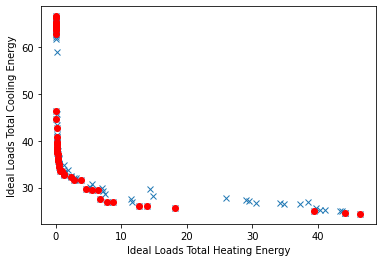

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_envelope_rb_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

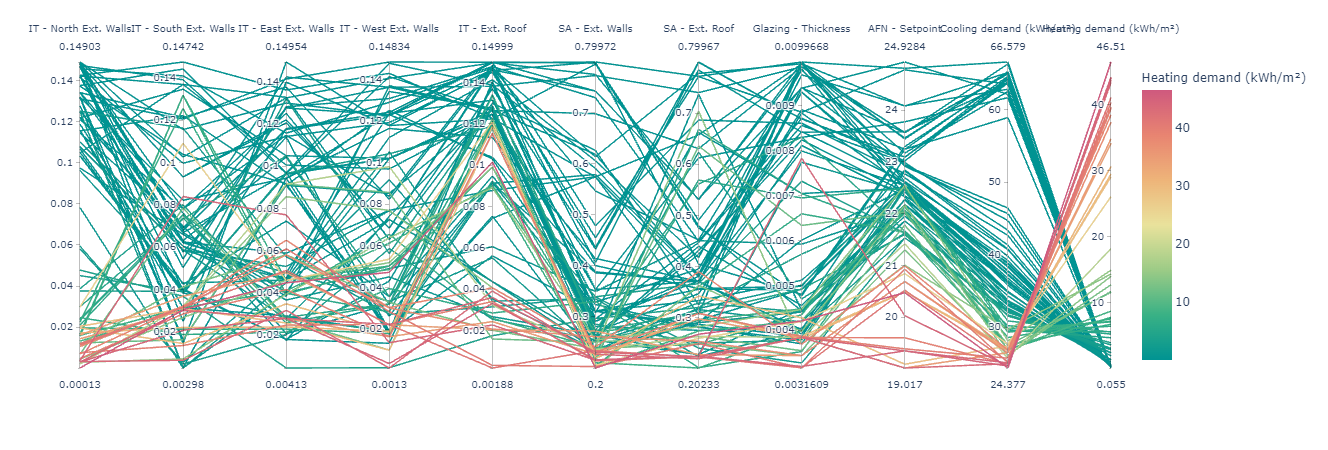

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.000129,0.030481,0.044610,0.047274,0.101536,0.200003,0.268244,0.004207,20.473032,24.377482,46.509835,0,True
1,0.149035,0.102582,0.132480,0.140510,0.149601,0.799716,0.771691,0.009967,24.806515,66.579495,0.055038,0,True
2,0.007580,0.013598,0.024487,0.022238,0.034066,0.213958,0.224549,0.003840,19.600346,24.919189,39.443866,0,True
3,0.002132,0.032159,0.091484,0.098025,0.032234,0.235700,0.264028,0.003843,21.416656,25.735812,18.188721,0,True
4,0.146865,0.067839,0.117819,0.124236,0.149950,0.797793,0.491019,0.009401,22.929093,46.431046,0.086939,0,True
5,0.147344,0.139037,0.096570,0.141309,0.126589,0.618610,0.379382,0.009681,24.083159,62.828498,0.080191,0,True
6,0.003676,0.083921,0.076877,0.013459,0.022720,0.215299,0.224954,0.007826,20.026762,24.636564,44.102387,0,True
7,0.011727,0.041226,0.057944,0.032852,0.020145,0.237859,0.249887,0.003432,21.299607,26.154067,12.704555,0,True
8,0.004462,0.026811,0.045839,0.051935,0.099153,0.200024,0.363455,0.003973,22.159375,26.082155,13.968248,0,True
9,0.013214,0.030481,0.044610,0.048597,0.099092,0.200003,0.274643,0.004207,22.172257,26.893562,8.689772,0,True


In [11]:
results.to_csv('../results/linear_envelope_rb_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
21,0.107954,0.058685,0.027584,0.072664,0.043705,0.235434,0.29075,0.004407,21.859666,32.639988,1.344648,0,True
